In [2]:
from trajectories import * 
from fourier_sig import * 
from fourier import * 
from utils import * 

## I. Martingality condition

In [3]:
d = 2
T = 1
logmoneyness = np.linspace(-0.25, 0.25, 100)
S0 = 1 
n = 252
n = 75

N = 1_000_000
W, paths = generate_paths(N, n, T)
W_perp = generate_brownian_paths(N, n, T)

In [12]:
M = 4
l_4 = np.zeros(iisignature.siglength(2, M)+1)
l_4[1:-1] = np.random.uniform(low=-0.5, high=0.5, size=(iisignature.siglength(2, M)-1))
l_4[0] = np.random.uniform(low=0.0, high=0.5)
l_4[-1] = 1
l_4

array([ 0.07155016, -0.14382186,  0.34029054, -0.25815024,  0.11035745,
       -0.27684414, -0.10471526, -0.41015655, -0.11957775, -0.07568969,
        0.48224074,  0.28821894,  0.01036551,  0.09526801, -0.25120429,
        0.26220333, -0.3044467 , -0.41990797,  0.31190746, -0.257773  ,
       -0.07381254, -0.35959365, -0.38019477,  0.38960036,  0.04875703,
        0.41384107, -0.36715296, -0.29545081, -0.29625381,  0.47487405,
        1.        ])

In [37]:
M = 5 
l_5 = np.zeros(iisignature.siglength(2, M)+1)
l_5[:iisignature.siglength(2, 4)+1] = l_4
l_5[iisignature.siglength(2, 4)+1:-1] = np.random.uniform(low=-0.5, high=0.5, size=(iisignature.siglength(2, M) - 1 - iisignature.siglength(2, 4)))
l_5[-1] = 1 
l_5

array([ 0.07155016, -0.14382186,  0.34029054, -0.25815024,  0.11035745,
       -0.27684414, -0.10471526, -0.41015655, -0.11957775, -0.07568969,
        0.48224074,  0.28821894,  0.01036551,  0.09526801, -0.25120429,
        0.26220333, -0.3044467 , -0.41990797,  0.31190746, -0.257773  ,
       -0.07381254, -0.35959365, -0.38019477,  0.38960036,  0.04875703,
        0.41384107, -0.36715296, -0.29545081, -0.29625381,  0.47487405,
        1.        , -0.01032849, -0.10580435, -0.30609199, -0.1791339 ,
        0.07647194, -0.2107639 , -0.33352903, -0.23752103,  0.45275565,
        0.07876466,  0.06006373,  0.36971803,  0.27033332, -0.01690561,
       -0.4893475 ,  0.01872723, -0.21955593,  0.09635399, -0.36476878,
        0.22809718,  0.08833473,  0.3650917 , -0.3139976 , -0.02303616,
       -0.34259684, -0.47328346,  0.27452029,  0.45826194,  0.20177827,
        0.19598134, -0.4980618 ,  1.        ])

In [6]:
rho = -0.9
B_minus_09 = rho * W + np.sqrt(1 - rho**2) * W_perp
rho = 0.9
B_plus_09 = rho * W + np.sqrt(1 - rho**2) * W_perp

In [7]:
M = 4 
sigma_4 = simulate_sigma(M, l_4[0], T, paths, l_4[1:], verbose=True, mode="vectorized", batch_size=10000) 
M = 5 
sigma_5 = simulate_sigma(M, l_5[0], T, paths, l_5[1:], verbose=True, mode="vectorized", batch_size=10000) 

100%|█████████████████████████████████████████| 100/100 [00:48<00:00,  2.07it/s]


In [8]:
rho = -0.9 
S_4_minus_09 = simulate_S_from_sigma(sigma_4, B_minus_09, S0, T)
S_5_minus_09 = simulate_S_from_sigma(sigma_5, B_minus_09, S0, T)

rho = 0.9 
S_4_plus_09 = simulate_S_from_sigma(sigma_4, B_plus_09, S0, T)
S_5_plus_09 = simulate_S_from_sigma(sigma_5, B_plus_09, S0, T)

In [12]:
iv_mc_call_4_minus_09, iv_lower_call_4_minus_09, iv_upper_call_4_minus_09 = compute_IV_MC(logmoneyness, T, S0, S_4_minus_09[:, -1], mode="call")
iv_mc_put_4_minus_09, iv_lower_put_4_minus_09, iv_upper_put_4_minus_09 = compute_IV_MC(logmoneyness, T, S0, S_4_minus_09[:, -1], mode="put")

iv_mc_call_5_minus_09, iv_lower_call_5_minus_09, iv_upper_call_5_minus_09 = compute_IV_MC(logmoneyness, T, S0, S_5_minus_09[:, -1], mode="call")
iv_mc_put_5_minus_09, iv_lower_put_5_minus_09, iv_upper_put_5_minus_09 = compute_IV_MC(logmoneyness, T, S0, S_5_minus_09[:, -1], mode="put")

iv_mc_call_4_plus_09, iv_lower_call_4_plus_09, iv_upper_call_4_plus_09 = compute_IV_MC(logmoneyness, T, S0, S_4_plus_09[:, -1], mode="call")
iv_mc_put_4_plus_09, iv_lower_put_4_plus_09, iv_upper_put_4_plus_09 = compute_IV_MC(logmoneyness, T, S0, S_4_plus_09[:, -1], mode="put")

iv_mc_call_5_plus_09, iv_lower_call_5_plus_09, iv_upper_call_5_plus_09 = compute_IV_MC(logmoneyness, T, S0, S_5_plus_09[:, -1], mode="call")
iv_mc_put_5_plus_09, iv_lower_put_5_plus_09, iv_upper_put_5_plus_09 = compute_IV_MC(logmoneyness, T, S0, S_5_plus_09[:, -1], mode="put")

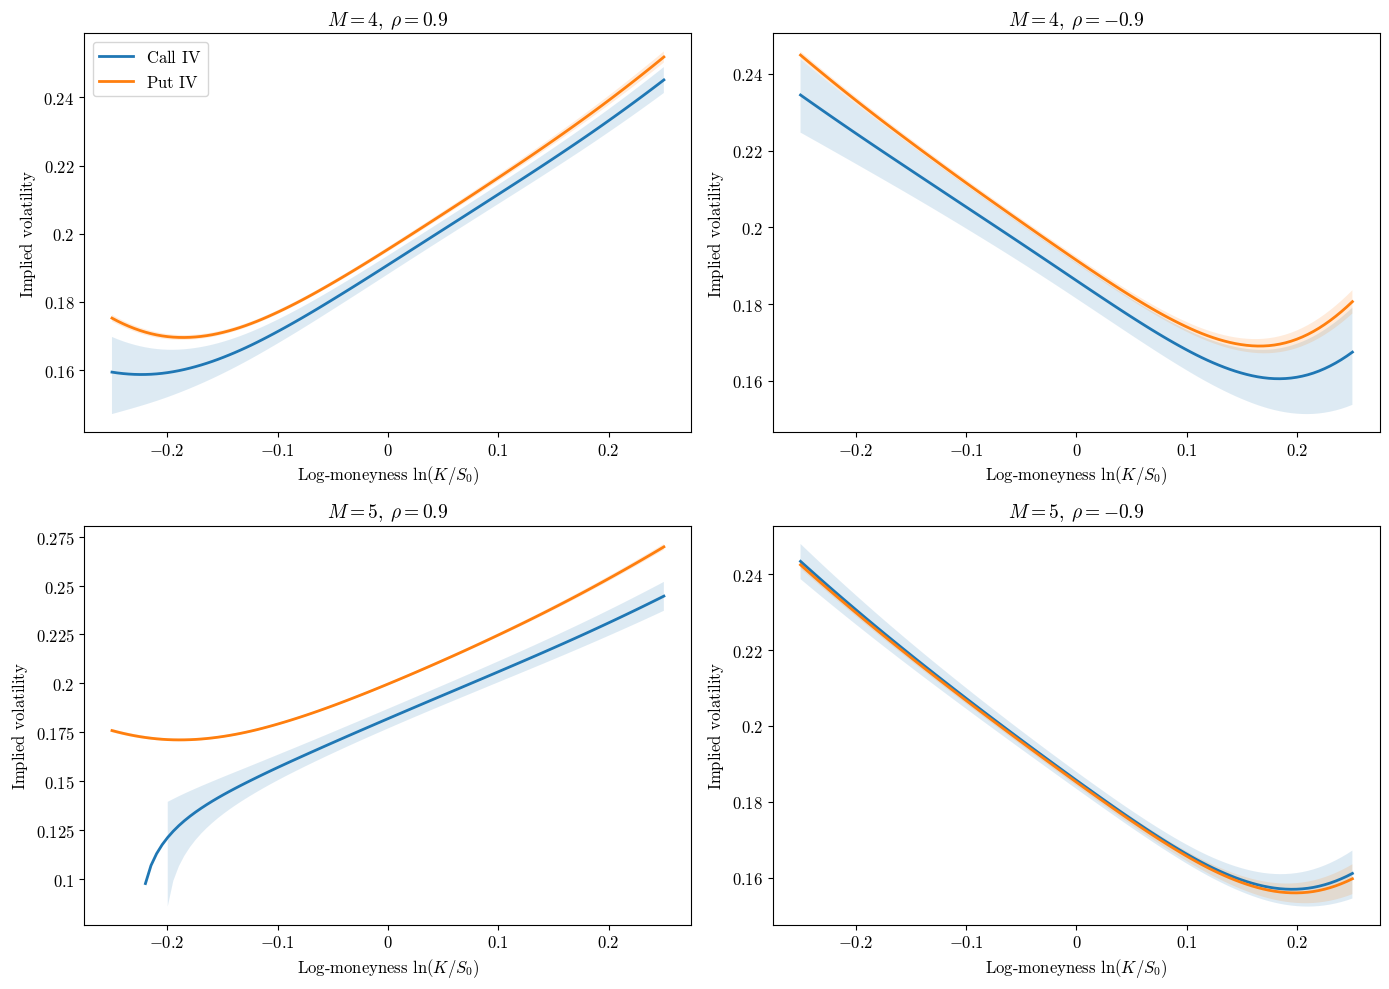

In [89]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.flatten()

ax[0].plot(logmoneyness, iv_mc_call_4_plus_09, lw=2, label=r"$\text{Call IV}$")
ax[0].fill_between(logmoneyness, iv_lower_call_4_plus_09, iv_upper_call_4_plus_09, alpha=0.15)
ax[0].plot(logmoneyness, iv_mc_put_4_plus_09, lw=2, label=r"$\text{Put IV}$")
ax[0].fill_between(logmoneyness, iv_lower_put_4_plus_09, iv_upper_put_4_plus_09, alpha=0.15)
ax[0].set_title(r"$M=4,\: \rho=0.9$", fontsize=14)

ax[1].plot(logmoneyness, iv_mc_call_4_minus_09, lw=2, label=r"$\text{Call IV}$")
ax[1].fill_between(logmoneyness, iv_lower_call_4_minus_09, iv_upper_call_4_minus_09, alpha=0.15)
ax[1].plot(logmoneyness, iv_mc_put_4_minus_09, lw=2, label=r"$\text{Put IV}$")
ax[1].fill_between(logmoneyness, iv_lower_put_4_minus_09, iv_upper_put_4_minus_09, alpha=0.15)
ax[1].set_title(r"$M=4,\: \rho=-0.9$", fontsize=14)

ax[2].plot(logmoneyness, iv_mc_call_5_plus_09, lw=2, label=r"$\text{Call IV}$")
ax[2].fill_between(logmoneyness, iv_lower_call_5_plus_09, iv_upper_call_5_plus_09, alpha=0.15)
ax[2].plot(logmoneyness, iv_mc_put_5_plus_09, lw=2, label=r"$\text{Put IV}$")
ax[2].fill_between(logmoneyness, iv_lower_put_5_plus_09, iv_upper_put_5_plus_09, alpha=0.15)
ax[2].set_title(r"$M=5,\: \rho=0.9$", fontsize=14)

ax[3].plot(logmoneyness, iv_mc_call_5_minus_09, lw=2, label=r"$\text{Call IV}$")
ax[3].fill_between(logmoneyness, iv_lower_call_5_minus_09, iv_upper_call_5_minus_09, alpha=0.15)
ax[3].plot(logmoneyness, iv_mc_put_5_minus_09, lw=2, label=r"$\text{Put IV}$")
ax[3].fill_between(logmoneyness, iv_lower_put_5_minus_09, iv_upper_put_5_minus_09, alpha=0.15)
ax[3].set_title(r"$M=5,\: \rho=-0.9$", fontsize=14)

for a in ax : 
    a.set_xlabel(r"$\text{Log-moneyness }\ln(K/S_0)$", fontsize=12) 
    a.set_ylabel(r"$\text{Implied volatility}$", fontsize=12)
    a.xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
    a.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    a.tick_params(labelsize=12, axis="both")
ax[0].legend(fontsize=12)

plt.tight_layout()
plt.show()

## II. Moments

In [35]:
d = 2
T = 1
S0 = 1 
n = 75

N = 2_000_000
W, paths = generate_paths(N, n, T)
W_perp = generate_brownian_paths(N, n, T)

In [36]:
M = 3
l_3 = np.zeros(iisignature.siglength(2, M)+1)
l_3[1:-1] = np.random.uniform(low=-0.5, high=0.5, size=(iisignature.siglength(2, M)-1))
l_3[0] = np.random.uniform(low=0.0, high=0.5)
l_3[-1] = 10
l_3

array([ 0.03634122,  0.03403978, -0.06477688,  0.05373084,  0.06966572,
        0.21583061, -0.43283537, -0.06524983, -0.29392447, -0.09480065,
        0.31089478,  0.24898183, -0.20446807, -0.32241204, 10.        ])

In [37]:
sigma_3 = simulate_sigma(M, l_3[0], T, paths, l_3[1:], verbose=True, mode="vectorized", batch_size=10000) 

100%|█████████████████████████████████████████| 200/200 [00:19<00:00, 10.06it/s]


In [42]:
logmoneyness = np.linspace(0, 2.0, 100)

In [43]:
rho = -0.7
B_minus_07 = rho * W + np.sqrt(1 - rho**2) * W_perp
S_minus_07 = simulate_S_from_sigma(sigma_3, B_minus_07, S0, T)

In [44]:
iv_mc_call_minus_07, iv_lower_call_minus_07, iv_upper_call_minus_07 = compute_IV_MC(logmoneyness, T, S0, S_minus_07[:, -1], mode="call")

In [45]:
rho = -0.7
beta_minus_07 = 2 * (1 - np.abs(rho))/(1 + np.abs(rho))
intercept_minus_07 = iv_mc_call_minus_07[-1]**2 * T - beta_minus_07 * logmoneyness[-1]

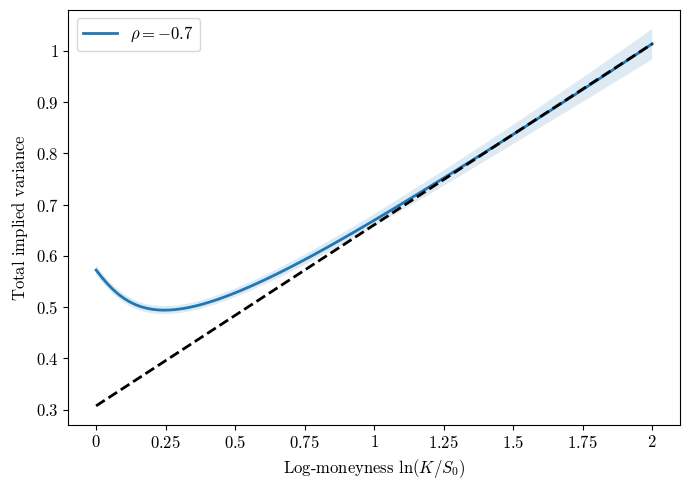

In [51]:
fig, ax = plt.subplots(figsize=(7,5))

ax.plot(logmoneyness, iv_mc_call_minus_07**2 * T, lw=2, label=r"$\rho=-0.7$")
ax.fill_between(logmoneyness, iv_lower_call_minus_07**2 * T, iv_upper_call_minus_07**2 * T, alpha=0.15)
ax.plot(logmoneyness, beta_minus_07 * logmoneyness + intercept_minus_07, lw=2, color="black", linestyle="--")

ax.set_xlabel(r"$\text{Log-moneyness }\ln(K/S_0)$", fontsize=12) 
ax.set_ylabel(r"$\text{Total implied variance}$", fontsize=12)
ax.xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
ax.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax.tick_params(labelsize=12, axis="both")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()